# Mixed-source propagator on a frozen shared latent space

One shared autoencoder is trained on 20 trajectories each from Reid, low-temperature de Pablo,
mixed-temperature de Pablo, and noisy LJ. Each trajectory is expressed in its initial-box coordinate system: the frame-zero box maps to [-1, 1] on both axes, and that fixed map is retained for all later frames. This removes absolute system size without removing strain. After freezing that shared representation, the propagator is trained on 20 low-temperature de Pablo trajectories plus 5 noisy-LJ trajectories; Real Reid and mixed-temperature dynamics remain held out. The autonomous model retains only z(1) and z(5), never any observation after frame 5, and receives no frame index, trajectory progress, source label, or temperature. The p-ratio is
never included in either training loss.


In [1]:
%matplotlib inline
import os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT/'src'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lss.latent.analysis import label_evaluation_sources
from lss.latent.experiment import latent_experiment_cache_key, run_latent_experiment, seed_everything
from lss.latent.simulation import pearson_r, r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
from lss.utils import resolve_device
apply_editorial_style()
DEVICE = resolve_device('auto')
print(f'Device: {DEVICE}')


Device: cuda


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
SEED = 34234  # Match notebook 08's noisy-LJ split seed.
COORDINATE_NORMALIZATION = 'position_normalization'
FORCE_TRAIN_AE = False
FORCE_TRAIN_PROPAGATORS = False
# Keep the shared paper representation at two learned latent coordinates.
LATENT_DIM = 2
TRAIN_TRAJECTORIES_PER_SOURCE = 20
VAL_TRAJECTORIES_PER_SOURCE = 5
ROLLOUT_STEPS = [25, 50, 75, 100, 125, 150, 175, 199]
TRAIN_STEPS_PER_SIM = 100
MAX_EPOCHS = 50
PATIENCE = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

# No source identity, temperature, box variable, p-ratio, frame index, or progress is supplied.
def require_dataset_path(label, *candidates):
    for candidate in candidates:
        path = Path(candidate).expanduser().resolve()
        if path.is_file():
            return path
    attempted = '\n'.join(f'  - {Path(candidate).expanduser()}' for candidate in candidates)
    raise FileNotFoundError(f'Missing {label} dataset. Tried:\n{attempted}')

DATASETS = {
    'reid': {
        'label': 'Reid', 'train_count': TRAIN_TRAJECTORIES_PER_SOURCE, 'val_count': VAL_TRAJECTORIES_PER_SOURCE,
        'path': PROJECT_ROOT/'data'/'reid_200_frames.pt',
    },
    'depablo_low_temp': {
        'label': 'de Pablo low-T', 'train_count': TRAIN_TRAJECTORIES_PER_SOURCE, 'val_count': VAL_TRAJECTORIES_PER_SOURCE,
        'path': require_dataset_path(
            'de Pablo low-T', PROJECT_ROOT/'data'/'depablo-near-zero-temp.pt'
        ),
    },
    'depablo_mixed_temp': {
        'label': 'de Pablo mixed-T', 'train_count': TRAIN_TRAJECTORIES_PER_SOURCE, 'val_count': VAL_TRAJECTORIES_PER_SOURCE,
        'path': require_dataset_path(
            'de Pablo mixed-T',
            PROJECT_ROOT/'data'/'depablo-10k-mix-temp.pt',
        ),
    },
    'lj_noisy': {
        'label': 'noisy LJ', 'train_count': TRAIN_TRAJECTORIES_PER_SOURCE, 'val_count': VAL_TRAJECTORIES_PER_SOURCE, 'test_eval_count': 100, 'edge_vector_dim': 2,
        'path': require_dataset_path(
            'noisy LJ',
            PROJECT_ROOT/'data'/'lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt',
        ),
    },
}
PROPAGATOR_TRAIN_TRAJECTORIES = {key: TRAIN_TRAJECTORIES_PER_SOURCE for key in DATASETS}
PROPAGATOR_VAL_TRAJECTORIES = {key: VAL_TRAJECTORIES_PER_SOURCE for key in DATASETS}
dataset_inventory = pd.DataFrame([
    {
        'source': key, 'path': str(spec['path']),
        'size_GB': spec['path'].stat().st_size / 1e9,
        'AE train': spec['train_count'],
        'propagator train': PROPAGATOR_TRAIN_TRAJECTORIES.get(key, 0),
        'validation': spec['val_count'],
    }
    for key, spec in DATASETS.items()
])
display(dataset_inventory.round({'size_GB': 2}))

AE_CONFIG = {
    'latent_dim': LATENT_DIM, 'latent_tokens': 32, 'hidden_size': 64,
    'model': 'single_stage_attention', 'batch_graphs': 256,
    'target_mode': 'normalized_delta', 'node_feature_mode': 'normalized_delta',
    'max_train_frames_per_sim': TRAIN_STEPS_PER_SIM + 1,
    'val_frame_skip': 1, 'max_val_frames_per_sim': TRAIN_STEPS_PER_SIM + 1,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE,
    'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY,
    # Every source contributes 20 trajectories and 150 sampled frames per trajectory.
    # Preserve every selected frame, but interleave all four sources per epoch.
    'balance_sources': False, 'mix_sources': True,
    'edge_mode': 'compact_stored',
    'edge_feature_schema': 'compact_unique_edge_changes_v1',
    'reference_context_mode': 'physical',
}
PROPAGATOR_CONFIG = {
    # Sample 100 distinct rollout starts spanning each selected 200-frame trajectory.
    'max_train_transitions_per_sim': TRAIN_STEPS_PER_SIM,
    # Strict one-step supervision: predict only z(t+1).
    'training_horizon': 1,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE,
    'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY, 'hidden_size': 64,
    'train_trajectories_per_source': PROPAGATOR_TRAIN_TRAJECTORIES,
    'val_trajectories_per_source': PROPAGATOR_VAL_TRAJECTORIES,
    'mix_sources': True,
    # The graph context contains learned reference-structure/interaction features only.
    'use_static_context': True, 'context_pool': 'moments', 'context_dim': 32,
    'rollout_eval_source': 'lj_noisy',
    'rollout_eval_sims_per_source': VAL_TRAJECTORIES_PER_SOURCE,
    'rollout_eval_horizons': [100, 150],
    'fixed_observed_frames': (1, 5),
}
assert max(PROPAGATOR_CONFIG['fixed_observed_frames']) <= 5
assert set(PROPAGATOR_TRAIN_TRAJECTORIES) == set(DATASETS)

OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'06c_shared_multiphysics_history_rollout'
OUTPUT.mkdir(parents=True, exist_ok=True)
AE_CACHE = OUTPUT/f'model_2d_all_sources_{TRAIN_TRAJECTORIES_PER_SOURCE}each_matched_budget_ae.pt'
MODEL_CACHE = OUTPUT/f'model_2d_all_sources_{TRAIN_TRAJECTORIES_PER_SOURCE}each_matched_budget_z1_z5.pt'
print({
    'ae_training_networks': sum(spec['train_count'] for spec in DATASETS.values()),
    'propagator_training_networks': sum(PROPAGATOR_TRAIN_TRAJECTORIES.values()),
    'validation_networks': sum(spec['val_count'] for spec in DATASETS.values()),
    'max_observed_frame': max(PROPAGATOR_CONFIG['fixed_observed_frames']),
    'latent_dim': LATENT_DIM,
    'ae_cache': str(AE_CACHE),
    'propagator_train_trajectories_by_source': PROPAGATOR_TRAIN_TRAJECTORIES,
    'rollout_starts_per_trajectory': PROPAGATOR_CONFIG['max_train_transitions_per_sim'],
    'training_horizon': PROPAGATOR_CONFIG['training_horizon'],
    'model_cache': str(MODEL_CACHE),
})


,source,path,size_GB,AE train,propagator train,validation
0,reid,/home/alexz/Documents/course_project/data/reid...,0.31,20,0,5
1,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,1.59,20,20,5
2,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,2.37,20,0,5
3,lj_noisy,/home/alexz/Documents/course_project/data/lj-n...,0.48,20,5,5


{'ae_training_networks': 80, 'propagator_training_networks': 25, 'validation_networks': 20, 'max_observed_frame': 5, 'latent_dim': 2, 'ae_cache': '/home/alexz/Documents/course_project/notebooks/results/06c_shared_multiphysics_history_rollout/model_mixed4source_2d_20each_lj200_physical_context_interleaved_ae.pt', 'propagator_train_trajectories_by_source': {'depablo_low_temp': 20, 'lj_noisy': 5}, 'rollout_starts_per_trajectory': 100, 'training_horizon': 1, 'model_cache': '/home/alexz/Documents/course_project/notebooks/results/06c_shared_multiphysics_history_rollout/model_2d_depablo20_noisy5_velocity_residual_z1_z5_100starts_onestep.pt'}


## Frozen shared autoencoder and data mixture

In [3]:
mixture = [
    {
        'name': key, 'label': spec['label'], 'path': str(spec['path']),
        'train_count': spec['train_count'], 'val_count': spec['val_count'],
        'edge_vector_dim': spec.get('edge_vector_dim', 2),
    }
    for key,spec in DATASETS.items()
]

def base_config():
    return {
        'dataset_name': 'mixed_four_sources_shared',
        'split_seed': SEED, 'split_stratify_temperature': False,
        'coordinate_normalization': COORDINATE_NORMALIZATION,
        'ae_config': {**AE_CONFIG, 'edge_feature_dim': 4},
        'min_train_p_ratio': None, 'device': str(DEVICE), 'pos_dim': 2,
        'frame_skip': 1, 'train_frame_start_order': 0,
        # The mixed stored-edge representation is 13D; training also derives
        # and verifies this value directly from the selected graphs.
        'rollout_steps_grid': ROLLOUT_STEPS,
        'early_stop_min_delta': 1e-5,
        'model_seed': SEED, 'repeat_idx': 1,
    }

def source_spec(label):
    experiment_config = base_config()
    return {
        'dataset_name': experiment_config['dataset_name'], 'source_name': 'four-source mixture',
        'label': label, 'path': str(next(iter(DATASETS.values()))['path']),
        'dataset_mixture': mixture,
    }

print('The AE and propagator preserve all selected rows while interleaving sources within every training epoch.')


The AE and propagator preserve all selected rows while interleaving sources within every training epoch.


In [4]:
ae_cfg = base_config()
ae_cfg.update({
    'should_rollout': False, 'should_train_propagator': False,
    'force_train': FORCE_TRAIN_AE, 'cache_path': str(AE_CACHE),
    'cache_require_matching_config': True,
})
ae_spec = source_spec('shared four-source interleaved AE')
seed_everything(SEED)
shared_ae_result = run_latent_experiment(ae_spec, ae_cfg, device=DEVICE)
display(shared_ae_result['split_info'])
normalization_audit = []
seen_sources = set()
for sim in shared_ae_result['train_data']:
    graph = sim[0]
    source = str(getattr(graph, 'source_name', 'unknown'))
    if source in seen_sources:
        continue
    seen_sources.add(source)
    bounds = np.array([graph.box.x1, graph.box.x2, graph.box.y1, graph.box.y2], dtype=float)
    half_width = 0.5 * (bounds[1] - bounds[0])
    half_height = 0.5 * (bounds[3] - bounds[2])
    if not (np.allclose([bounds[0]+bounds[1], bounds[2]+bounds[3]], 0.0, atol=1e-6) and np.isclose(half_width*half_height, 1.0, atol=1e-5)):
        raise RuntimeError(f'{source} initial box does not use the isotropic unit-area convention: {bounds}')
    normalization_audit.append({
        'source': source, 'x_min': bounds[0], 'x_max': bounds[1],
        'y_min': bounds[2], 'y_max': bounds[3],
        'coordinate_system': getattr(graph, 'coordinate_normalization', 'missing'),
    })
display(pd.DataFrame(normalization_audit).sort_values('source').reset_index(drop=True))
display(shared_ae_result['ae_history'].tail())

ignoring stale latent cache (configuration changed): /home/alexz/Documents/course_project/notebooks/results/06c_shared_multiphysics_history_rollout/model_mixed4source_2d_20each_lj200_physical_context_interleaved_ae.pt



=== shared four-source interleaved AE ===
            source                                                                                                 path  total  train  reserved_train_pool  val  test
              reid                                         /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     20                   20    5    77
  depablo_low_temp                                  /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     20                   20    5   175
depablo_mixed_temp                                    /home/alexz/Documents/course_project/data/depablo-10k-mix-temp.pt    300     20                   20    5   275
          lj_noisy /home/alexz/Documents/course_project/data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt    200     20                   20    5   175
source-mixed AE coverage: {'reid': {'trajectories': 20, 'frames': 2000}, 'depablo_low_temp': {'trajectories': 20, 'frames': 200

,source,path,total,train,reserved_train_pool,val,test
0,reid,/home/alexz/Documents/course_project/data/reid...,102,20,20,5,77
1,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,20,20,5,175
2,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,20,20,5,275
3,lj_noisy,/home/alexz/Documents/course_project/data/lj-n...,200,20,20,5,175


,source,x_min,x_max,y_min,y_max,coordinate_system
0,depablo_low_temp,-0.999963,0.999963,-1.000037,1.000037,position_normalization
1,depablo_mixed_temp,-1.000620,1.000620,-0.999380,0.999380,position_normalization
2,lj_noisy,-1.014832,1.014832,-0.985385,0.985385,position_normalization
3,reid,-1.000000,1.000000,-1.000000,1.000000,position_normalization


,epoch,train_objective,val_objective,train_mse_norm,val_mse_norm,dataset,latent_dim,target_mode,hidden_size
31,32,0.383781,0.431109,0.383781,0.431109,shared four-source interleaved AE,2,normalized_delta,64
32,33,0.381825,0.432582,0.381825,0.432582,shared four-source interleaved AE,2,normalized_delta,64
33,34,0.386480,0.432608,0.386480,0.432608,shared four-source interleaved AE,2,normalized_delta,64
34,35,0.382396,0.434038,0.382396,0.434038,shared four-source interleaved AE,2,normalized_delta,64
35,36,0.378688,0.432193,0.378688,0.432193,shared four-source interleaved AE,2,normalized_delta,64


## Train the mixed-source fixed-(1,5) velocity-residual propagator

The frozen AE uses 20 training trajectories from every source. The propagator then uses 20 low-temperature de Pablo trajectories and 5 noisy-LJ trajectories only. Every selected trajectory contributes up to 100 one-step transitions; there is no global row cap. Rows are shuffled across the two training sources rather than processed in source blocks. Training predicts z(t+1) from the current latent, fixed z(1), fixed z(5), and static graph context. Real Reid and mixed-temperature dynamics are not used for propagator fitting. Checkpoint selection uses five noisy-LJ validation trajectories because noisy-LJ rollout is the target stress test.

In [5]:
PROPAGATOR_MODES = {
    'history': {
        'label': f"fixed z({PROPAGATOR_CONFIG['fixed_observed_frames'][0]}), z({PROPAGATOR_CONFIG['fixed_observed_frames'][1]})",
        'objective': 'fixed_history_one_step',
        'model': 'fixed_velocity_residual_mlp',
        'fixed_observed_frames': PROPAGATOR_CONFIG['fixed_observed_frames'],
    },
}

PROPAGATOR_RUN_COMPLETE = False
results = {}
model_cache_keys = {}
for mode_key, mode in PROPAGATOR_MODES.items():
    experiment_config = base_config()
    prop_cache = MODEL_CACHE
    experiment_config.update({
        # Reuse the known-good frozen AE while training a fresh propagator bundle.
        'pretrained_ae_cache_path': str(AE_CACHE),
        'pretrained_ae_require_matching_normalizers': True,
        'pretrained_ae_config_keys': [
            'latent_dim', 'latent_tokens', 'hidden_size', 'autoencoder_model',
            'batch_graphs', 'ae_max_train_frames_per_sim', 'ae_val_frame_skip',
            'ae_max_val_frames_per_sim', 'ae_max_epochs', 'ae_patience',
            'ae_lr', 'ae_weight_decay', 'ae_balance_sources', 'ae_mix_sources',
            'node_feature_mode', 'ae_target_mode', 'coordinate_normalization', 'reference_context_mode',
            'split_seed', 'dataset_mixture',
        ],
        'force_train_autoencoder': FORCE_TRAIN_AE,
        'propagator_config': {
            **PROPAGATOR_CONFIG, 'balance_sources': False,
            'objective': mode['objective'], 'model': mode['model'],
            'loss': 'delta', 'step_stride': 1,
        # The history trainer uses the same row format for all horizons; [1]
        # is strict teacher-forced one-step supervision with no unroll curriculum.
            'multistep_horizons': [PROPAGATOR_CONFIG['training_horizon']],
            'rollout_eval_every_epoch': True,
        },
        # Select explicitly for noisy-LJ rollout performance.
        'rollout_eval_max_sims_by_split': {
            'train': TRAIN_TRAJECTORIES_PER_SOURCE,
            'val': VAL_TRAJECTORIES_PER_SOURCE,
            'test': DATASETS['lj_noisy']['test_eval_count'],
        },
        'rollout_eval_source': 'lj_noisy',
        # Epoch callbacks already cover validation; final evaluation is held-out test only.
        'rollout_eval_splits': ['test'],
        'should_rollout': True, 'should_train_propagator': True,
        'force_train': FORCE_TRAIN_AE or FORCE_TRAIN_PROPAGATORS,
        'cache_path': str(prop_cache),
        'cache_require_matching_config': True,
    })
    if 'fixed_observed_frames' in mode:
        experiment_config['fixed_observed_frames'] = tuple(mode['fixed_observed_frames'])
    spec = source_spec(f"mixed-source {mode['label']} propagator on frozen shared AE")
    model_cache_keys[mode_key] = latent_experiment_cache_key(spec, experiment_config)
    print(f"Training/loading propagator: {mode['label']} ...", flush=True)
    seed_everything(SEED)
    results[mode_key] = run_latent_experiment(spec, experiment_config, device=DEVICE)
    history = results[mode_key]['dyn_history'].copy()
    display(history.tail())
PROPAGATOR_RUN_COMPLETE = set(results) == set(PROPAGATOR_MODES)
assert PROPAGATOR_RUN_COMPLETE, 'Not every propagator completed successfully.'
display(results['history']['split_info'])
display(results['history']['ae_history'].tail())


Training/loading propagator: fixed z(1), z(5) ...
ignoring stale latent cache (configuration changed): /home/alexz/Documents/course_project/notebooks/results/06c_shared_multiphysics_history_rollout/model_2d_depablo20_noisy5_velocity_residual_z1_z5_100starts_onestep.pt

=== mixed-source fixed z(1), z(5) propagator on frozen shared AE ===
            source                                                                                                 path  total  train  reserved_train_pool  val  test
              reid                                         /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     20                   20    5    77
  depablo_low_temp                                  /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     20                   20    5   175
depablo_mixed_temp                                    /home/alexz/Documents/course_project/data/depablo-10k-mix-temp.pt    300     20                   20    5   2

,epoch,train_loss,val_loss,train_dz_mse_norm,train_loss_raw,train_position_loss,val_dz_mse_norm,val_dz_mse_raw,val_position_loss,val_rollout_p_ratio_r2,...,dataset,latent_dim,target_mode,hidden_size,propagator_loss,propagator_objective,propagator_multistep_horizons,propagator_multistep_loss,propagator_step_stride,initial_velocity
23,24,0.415515,1.382967,0.415515,0.000014,0.0,1.382967,0.000042,0.0,0.196298,...,"mixed-source fixed z(1), z(5) propagator on fr...",2,normalized_delta,64,delta,fixed_history_one_step,[1],all_steps_plus_optional_decoded_endpoint,1,zero
24,25,0.404888,1.394705,0.404888,0.000014,0.0,1.394705,0.000043,0.0,0.198552,...,"mixed-source fixed z(1), z(5) propagator on fr...",2,normalized_delta,64,delta,fixed_history_one_step,[1],all_steps_plus_optional_decoded_endpoint,1,zero
25,26,0.396231,1.404848,0.396231,0.000013,0.0,1.404848,0.000043,0.0,0.200752,...,"mixed-source fixed z(1), z(5) propagator on fr...",2,normalized_delta,64,delta,fixed_history_one_step,[1],all_steps_plus_optional_decoded_endpoint,1,zero
26,27,0.384754,1.410653,0.384754,0.000013,0.0,1.410653,0.000043,0.0,0.199339,...,"mixed-source fixed z(1), z(5) propagator on fr...",2,normalized_delta,64,delta,fixed_history_one_step,[1],all_steps_plus_optional_decoded_endpoint,1,zero
27,28,0.373032,1.416072,0.373032,0.000013,0.0,1.416072,0.000043,0.0,0.199222,...,"mixed-source fixed z(1), z(5) propagator on fr...",2,normalized_delta,64,delta,fixed_history_one_step,[1],all_steps_plus_optional_decoded_endpoint,1,zero


,source,path,total,train,reserved_train_pool,val,test
0,reid,/home/alexz/Documents/course_project/data/reid...,102,20,20,5,77
1,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,20,20,5,175
2,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,20,20,5,275
3,lj_noisy,/home/alexz/Documents/course_project/data/lj-n...,200,20,20,5,175


,epoch,train_objective,val_objective,train_mse_norm,val_mse_norm,dataset,latent_dim,target_mode,hidden_size
31,32,0.383781,0.431109,0.383781,0.431109,"mixed-source fixed z(1), z(5) propagator on fr...",2,normalized_delta,64
32,33,0.381825,0.432582,0.381825,0.432582,"mixed-source fixed z(1), z(5) propagator on fr...",2,normalized_delta,64
33,34,0.386480,0.432608,0.386480,0.432608,"mixed-source fixed z(1), z(5) propagator on fr...",2,normalized_delta,64
34,35,0.382396,0.434038,0.382396,0.434038,"mixed-source fixed z(1), z(5) propagator on fr...",2,normalized_delta,64
35,36,0.378688,0.432193,0.378688,0.432193,"mixed-source fixed z(1), z(5) propagator on fr...",2,normalized_delta,64


## Propagator optimization history

Only noisy-LJ validation rollouts are performed during training. The selected checkpoint maximizes mean noisy-LJ p-ratio R² across frames 100 and 150. The AE stays frozen throughout.


Selected noisy-LJ checkpoint: epoch 16, validation rollout R²=0.213


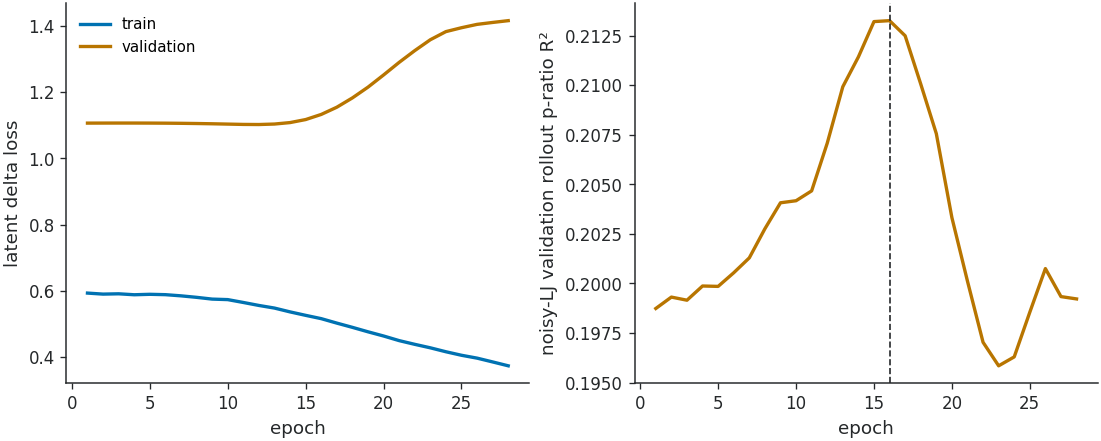

,epoch,train_loss,val_loss,val_rollout_source_lj_noisy_p_ratio_r2
18,19,0.4758,1.2151,0.2076
19,20,0.4631,1.2519,0.2033
20,21,0.4492,1.2900,0.2001
21,22,0.4380,1.3255,0.1970
22,23,0.4274,1.3584,0.1958
23,24,0.4155,1.3830,0.1963
24,25,0.4049,1.3947,0.1986
25,26,0.3962,1.4048,0.2008
26,27,0.3848,1.4107,0.1993
27,28,0.3730,1.4161,0.1992


In [6]:
assert PROPAGATOR_RUN_COMPLETE, 'Run the propagator-training cell first.'
result = results['history']
dyn_history = result['dyn_history'].copy()
LJ_CHECKPOINT_METRIC = 'val_rollout_source_lj_noisy_p_ratio_r2'

finite_selection = dyn_history.replace([np.inf, -np.inf], np.nan).dropna(subset=[LJ_CHECKPOINT_METRIC])
if finite_selection.empty:
    best_row = dyn_history.loc[dyn_history.val_loss.idxmin()]
    print(f"No finite noisy-LJ validation rollout R² was available; selected epoch {int(best_row.epoch)} by validation loss.")
else:
    best_row = finite_selection.loc[finite_selection[LJ_CHECKPOINT_METRIC].idxmax()]
    print(f"Selected noisy-LJ checkpoint: epoch {int(best_row.epoch)}, validation rollout R²={best_row[LJ_CHECKPOINT_METRIC]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7), constrained_layout=True)
axes[0].plot(dyn_history.epoch, dyn_history.train_loss, color=PAPER_COLORS['blue'], label='train')
axes[0].plot(dyn_history.epoch, dyn_history.val_loss, color=PAPER_COLORS['orange'], label='validation')
style_axes(axes[0], xlabel='epoch', ylabel='latent delta loss', legend=True)
axes[1].plot(dyn_history.epoch, dyn_history[LJ_CHECKPOINT_METRIC], color=PAPER_COLORS['orange'])
axes[1].axvline(best_row.epoch, color=PAPER_COLORS['ink'], linestyle='--', linewidth=1)
style_axes(axes[1], xlabel='epoch', ylabel='noisy-LJ validation rollout p-ratio R²', legend=False)
plt.show()

display(dyn_history.loc[:, [column for column in [
    'epoch', 'train_loss', 'val_loss', LJ_CHECKPOINT_METRIC,
] if column in dyn_history]].tail(10).round(4))


## Held-out noisy-LJ rollout versus the AE ceiling

The AE ceiling encodes and decodes the true latent at every requested frame. The propagator must instead advance recursively from the fixed observations z(1) and z(5). Both trajectory and endpoint p-ratio estimators are reported on the same 100 held-out noisy-LJ networks.


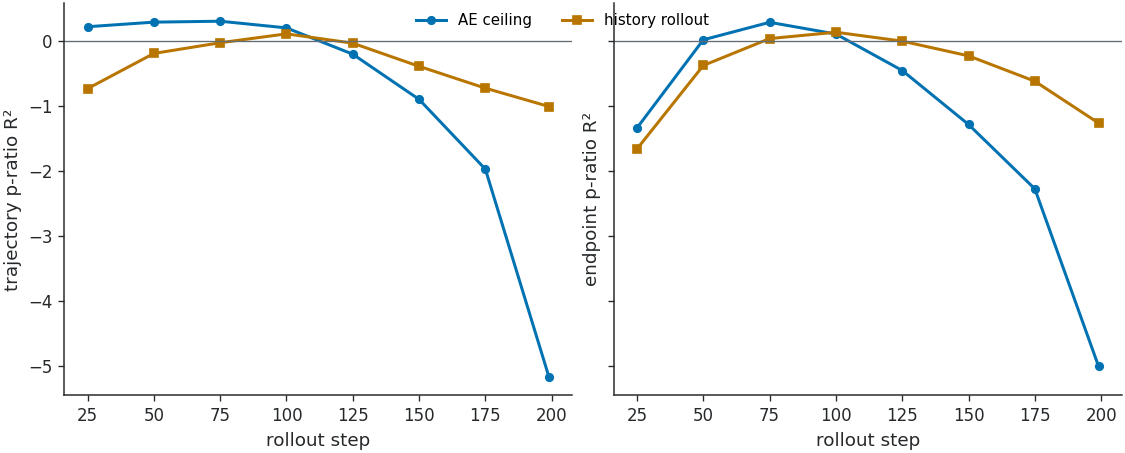

,representation,estimator,rollout_steps,p_ratio_r2,pearson_r,position_mse,n_networks
3,AE ceiling,trajectory,100,0.2009,0.4651,0.0000,100
5,AE ceiling,trajectory,150,-0.8994,-0.4861,0.0000,100
7,AE ceiling,trajectory,199,-5.1764,-0.5002,0.0001,100
11,AE ceiling,endpoint,100,0.1063,0.3328,0.0000,100
13,AE ceiling,endpoint,150,-1.2861,-0.5600,0.0000,100
15,AE ceiling,endpoint,199,-5.0050,-0.3928,0.0001,100
19,history rollout,trajectory,100,0.1091,0.3720,0.0000,100
21,history rollout,trajectory,150,-0.3908,-0.1988,0.0000,100
23,history rollout,trajectory,199,-1.0097,-0.3592,0.0001,100
27,history rollout,endpoint,100,0.1342,0.3721,0.0000,100


In [7]:
SOURCE_LABELS = {key: spec['label'] for key, spec in DATASETS.items()}
LJ_LABEL = SOURCE_LABELS['lj_noisy']

rollout_rows = label_evaluation_sources(
    result['rollout_rows'].query("split == 'test'"), SOURCE_LABELS,
)
rollout_rows = rollout_rows[rollout_rows.source_family.eq(LJ_LABEL)].copy()
lj_indices = rollout_rows.sim_idx.drop_duplicates().iloc[:DATASETS['lj_noisy']['test_eval_count']]
rollout_rows = rollout_rows[rollout_rows.sim_idx.isin(lj_indices)].copy()

ae_rows = label_evaluation_sources(
    result['ae_reconstruction_rows'].query("split == 'test'"), SOURCE_LABELS,
)
ae_rows = ae_rows[
    ae_rows.source_family.eq(LJ_LABEL) & ae_rows.sim_idx.isin(lj_indices)
].copy()
rollout_rows.to_csv(OUTPUT/'noisy_lj_rollout_rows.csv', index=False)

summary_rows = []
estimators = {
    'trajectory': ('true_p_ratio', 'pred_p_ratio'),
    'endpoint': ('endpoint_true_p_ratio', 'endpoint_pred_p_ratio'),
}
for representation, frame in [('AE ceiling', ae_rows), ('history rollout', rollout_rows)]:
    for estimator, (true_col, pred_col) in estimators.items():
        for step, group in frame.groupby('rollout_steps'):
            valid = group[[true_col, pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
            position_error = group.final_pos_mse.replace([np.inf, -np.inf], np.nan).dropna()
            summary_rows.append({
                'representation': representation,
                'estimator': estimator,
                'rollout_steps': int(step),
                'p_ratio_r2': r2_score(valid[true_col], valid[pred_col]) if len(valid) >= 2 else np.nan,
                'pearson_r': pearson_r(valid[true_col], valid[pred_col]) if len(valid) >= 2 else np.nan,
                'position_mse': position_error.mean(),
                'n_networks': len(valid),
            })
rollout_summary = pd.DataFrame(summary_rows)
rollout_summary.to_csv(OUTPUT/'noisy_lj_propagator_vs_ae_ceiling.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.8), sharex=True, sharey=True, constrained_layout=True)
for ax, estimator in zip(axes, estimators):
    for representation, color, marker in [
        ('AE ceiling', PAPER_COLORS['blue'], 'o'),
        ('history rollout', PAPER_COLORS['orange'], 's'),
    ]:
        group = rollout_summary[
            rollout_summary.estimator.eq(estimator)
            & rollout_summary.representation.eq(representation)
        ].sort_values('rollout_steps')
        ax.plot(group.rollout_steps, group.p_ratio_r2, color=color, marker=marker,
                linewidth=1.8, markersize=4.5, label=representation)
    ax.axhline(0, color=PAPER_COLORS['slate'], linewidth=.8)
    style_axes(ax, xlabel='rollout step', ylabel=f'{estimator} p-ratio R²', legend=False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
plt.show()

display(rollout_summary[rollout_summary.rollout_steps.isin([100, 150, 199])].round(4))


## Noisy-LJ rollout calibration

These held-out scatter plots expose bias and range compression that a single aggregate R² can hide.


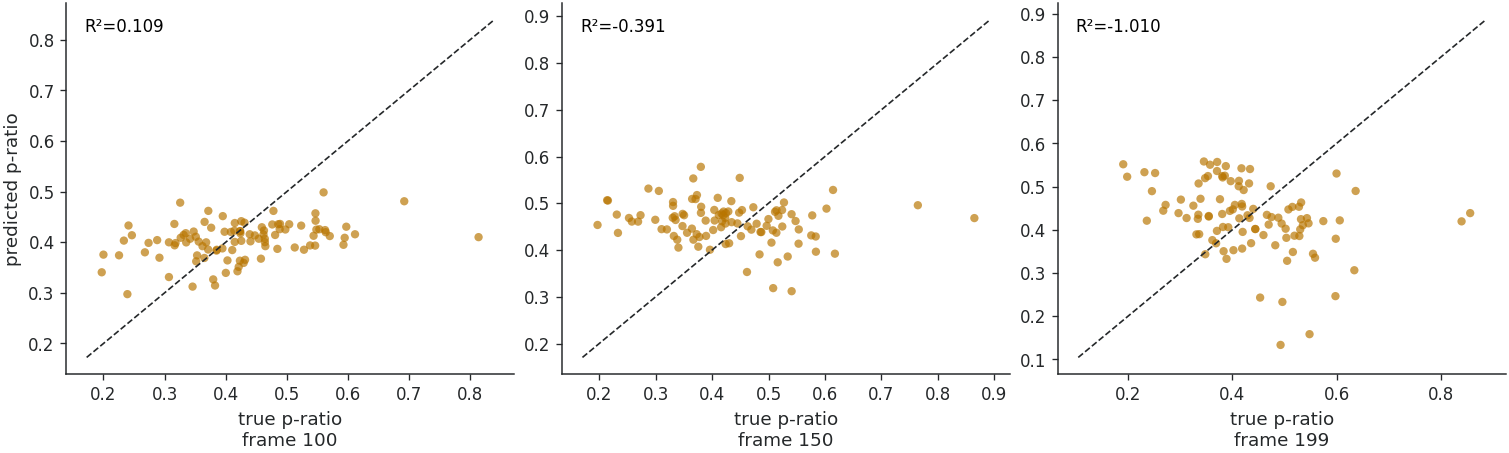

In [8]:
SCATTER_HORIZONS = [100, 150, 199]
fig, axes = plt.subplots(1, len(SCATTER_HORIZONS), figsize=(12.6, 3.8), constrained_layout=True)
for ax, step in zip(axes, SCATTER_HORIZONS):
    group = rollout_rows[rollout_rows.rollout_steps.eq(step)].replace(
        [np.inf, -np.inf], np.nan,
    ).dropna(subset=['true_p_ratio', 'pred_p_ratio'])
    ax.scatter(group.true_p_ratio, group.pred_p_ratio, s=25, alpha=.68,
               color=PAPER_COLORS['orange'], edgecolor='none')
    if len(group):
        limits = np.r_[group.true_p_ratio, group.pred_p_ratio]
        lo, hi = np.nanmin(limits), np.nanmax(limits)
        pad = .04 * max(hi - lo, 1e-6)
        ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], '--', color=PAPER_COLORS['ink'], linewidth=1)
    score = rollout_summary[
        rollout_summary.representation.eq('history rollout')
        & rollout_summary.estimator.eq('trajectory')
        & rollout_summary.rollout_steps.eq(step)
    ]
    annotation = 'R² unavailable' if score.empty else f"R²={score.p_ratio_r2.iloc[0]:.3f}"
    ax.text(.04, .96, annotation, transform=ax.transAxes, ha='left', va='top')
    style_axes(ax, xlabel=f'true p-ratio\nframe {step}', ylabel='predicted p-ratio' if ax is axes[0] else '', legend=False)
plt.show()
